# **Data Wrangling Lab**


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
# Display column data types and non-null columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


In [4]:
# Count missing values per column
missing_summary = df.isnull().sum().sort_values(ascending=False)

# Display top 15 columns with most missing values
print(missing_summary.head(15))

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
dtype: int64


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [5]:
# Generate summary statistics for numerical columns
numeric_summary = df.describe()
print(numeric_summary)

         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    29411.000000    29450.000000     29448.00000   
mean         7.522140       10.060857       24.343232        22.96522   
std         18.422661       21.833836       27.089360        27.01774   
min          0.000000        0.000000        0.000000         0.00000   
25%          0.000000 

In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Numeric columns:", numeric_cols)

Numeric columns: Index(['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1',
       'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7',
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat'],
      dtype='str')


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [7]:
# Check unique values in Country column
unique_countries = df["Country"].unique()
print(unique_countries)

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
            

In [8]:
# Example: filter out entries that are too rare or irrelevant
inconsistent_entries = df["Country"].value_counts()[df["Country"].value_counts() < 5]
print("Potential inconsistent/irrelevant entries:\n", inconsistent_entries)

Potential inconsistent/irrelevant entries:
 Country
Liechtenstein                            4
Fiji                                     4
Gabon                                    4
Bahamas                                  4
Lao People's Democratic Republic         4
Swaziland                                4
Burkina Faso                             4
Libyan Arab Jamahiriya                   4
Liberia                                  4
San Marino                               3
Democratic Republic of the Congo         3
Burundi                                  3
Sierra Leone                             3
North Korea                              3
Guyana                                   3
Brunei Darussalam                        3
Bhutan                                   3
Monaco                                   3
Democratic People's Republic of Korea    2
Guinea-Bissau                            2
Belize                                   2
Mali                                     2
Do

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [9]:
# Check unique values in Country and EdLevel
print(df["Country"].unique()[:20]) 
print(df["EdLevel"].unique()[:20])  

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
                                                'India',
                                              'Germany',
                                              'Ireland',
                                                'Italy',
                                              'Ukraine',
                                            'Australia',
                                               'Brazil',
                 

In [10]:
# Example mappings for Country
country_mapping = {
    "USA": "United States",
    "U.S.A.": "United States",
    "UK": "United Kingdom",
    "Indai": "India",
    "England": "United Kingdom"
}

# Example mappings for EdLevel
edlevel_mapping = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor’s degree",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master’s degree",
    "Primary/elementary school": "Primary school",
    "Secondary school (e.g. American high school, GCSEs, etc.)": "Secondary school",
    "Some college/university study without earning a degree": "Some college"
}

In [11]:
# Apply mappings to standardize values
df["Country"] = df["Country"].replace(country_mapping)
df["EdLevel"] = df["EdLevel"].replace(edlevel_mapping)

In [12]:
# Check standardized values
print(df["Country"].value_counts().head(10))
print(df["EdLevel"].value_counts().head(10))

Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Name: count, dtype: int64
EdLevel
Bachelor’s degree                                                                     24942
Master’s degree                                                                       15557
Some college                                                                           7651
Secondary school (e.g. American high school, German Realschule

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [13]:
# Check unique categories in Employment
print(df["Employment"].unique())

<StringArray>
[                                                                                                                                                          'Employed, full-time',
                                                                                                                                                            'Student, full-time',
                                                                                                                         'Student, full-time;Not employed, but looking for work',
                                                                                                                          'Independent contractor, freelancer, or self-employed',
                                                                                                                                        'Not employed, and not looking for work',
                                                                                                

In [14]:
# One-hot encode Employment column
employment_encoded = pd.get_dummies(df["Employment"], prefix="Employment")
df = pd.concat([df, employment_encoded], axis=1)

In [15]:
# Preview encoded columns
print(df.head()[["Employment", "Employment_Employed, full-time", "Employment_Student, full-time"]])

            Employment  Employment_Employed, full-time  \
0  Employed, full-time                            True   
1  Employed, full-time                            True   
2  Employed, full-time                            True   
3   Student, full-time                           False   
4   Student, full-time                           False   

   Employment_Student, full-time  
0                          False  
1                          False  
2                          False  
3                           True  
4                           True  


### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [16]:
# Count missing values in each column
missing_counts = df.isnull().sum().sort_values(ascending=False)

# Display top 10 columns with most missing values
print(missing_counts.head(10))

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
dtype: int64


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a summary DataFrame
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": missing_percentage,
    "Data Type": df.dtypes
}).sort_values(by="Missing Values", ascending=False)

# Display top 10
print(missing_report.head(10))

                               Missing Values  Missing % Data Type
AINextMuch less integrated              64289  98.245641       str
AINextLess integrated                   63082  96.401119       str
AINextNo change                         52939  80.900714       str
AINextMuch more integrated              51999  79.464217       str
EmbeddedAdmired                         48704  74.428840       str
EmbeddedWantToWorkWith                  47837  73.103901       str
EmbeddedHaveWorkedWith                  43223  66.052845       str
ConvertedCompYearly                     42002  64.186928   float64
AIToolNot interested in Using           41023  62.690832       str
AINextMore integrated                   41009  62.669438       str


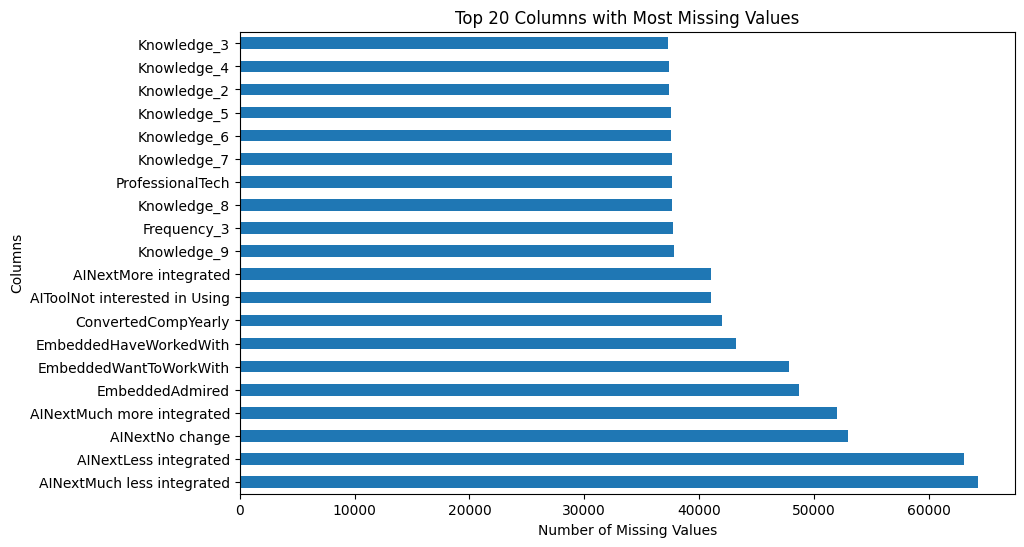

In [18]:
import matplotlib.pyplot as plt

# Plot missing values for top 20 columns
missing_report.head(20).plot(
    kind="barh", 
    y="Missing Values", 
    legend=False, 
    figsize=(10,6)
)
plt.title("Top 20 Columns with Most Missing Values")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [22]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical columns:", numeric_cols)

Numerical columns: Index(['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1',
       'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7',
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat'],
      dtype='str')


In [23]:
# Impute missing values with mean
for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_863/1294511926.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


In [25]:
# Impute missing values with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Check if missing values remain
print(df[numeric_cols].isnull().sum())

ResponseId                 0
CompTotal              31697
WorkExp                35779
JobSatPoints_1         36113
JobSatPoints_4         36044
JobSatPoints_5         36026
JobSatPoints_6         35987
JobSatPoints_7         35989
JobSatPoints_8         35981
JobSatPoints_9         35981
JobSatPoints_10        35987
JobSatPoints_11        35992
ConvertedCompYearly    42002
JobSat                 36311
dtype: int64


/tmp/ipykernel_863/2157296723.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_863/2157296723.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to upd

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [26]:
# Select categorical (object or string) columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index(['MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize',
       'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse',
       'Country', 'Currency', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith',
       'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'ToolsTechAdmired',
       'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith',
       'NEWCollabToolsAdmired', 'OpSysPersonal use', '

/tmp/ipykernel_863/3980159726.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [27]:
# Check the most frequent value in RemoteWork
most_frequent_remote = df["RemoteWork"].mode()[0]
print("Most frequent value in RemoteWork:", most_frequent_remote)

Most frequent value in RemoteWork: Hybrid (some remote, some in-person)


In [29]:
# Fill missing values in RemoteWork with the most frequent value
df["RemoteWork"].fillna(most_frequent_remote, inplace=True)

# Impute missing values in all categorical columns with their most frequent value
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_863/151240336.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["RemoteWork"].fillna(most_frequent_remote, inplace=True)
/tmp/ipykernel_863/151240336.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never w

In [30]:
# Check if missing values remain in categorical columns
print(df[categorical_cols].isnull().sum())

MainBranch                  0
Age                         0
Employment                  0
RemoteWork              10631
Check                       0
                        ...  
ProfessionalCloud       36946
ProfessionalQuestion    36630
Industry                36579
SurveyLength             9255
SurveyEase               9199
Length: 100, dtype: int64


### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [31]:
!pip install scikit-learn


In [32]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
# Initialize scaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to ConvertedCompYearly
df["ConvertedCompYearly_MinMax"] = scaler.fit_transform(df[["ConvertedCompYearly"]])

# Preview original vs normalized values
print(df[["ConvertedCompYearly", "ConvertedCompYearly_MinMax"]].head())

   ConvertedCompYearly  ConvertedCompYearly_MinMax
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN


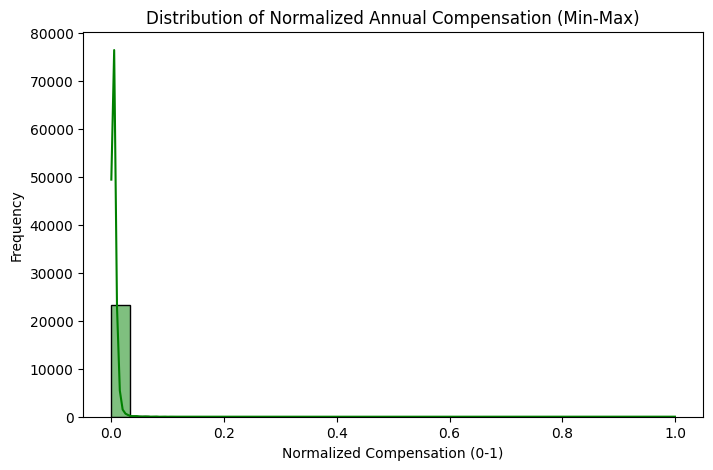

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["ConvertedCompYearly_MinMax"].dropna(), bins=30, kde=True, color="green")
plt.title("Distribution of Normalized Annual Compensation (Min-Max)")
plt.xlabel("Normalized Compensation (0-1)")
plt.ylabel("Frequency")
plt.show()

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [36]:
# Replace missing values with median (or mean) before log-transform
df["ConvertedCompYearly"].fillna(df["ConvertedCompYearly"].median(), inplace=True)

# Ensure no zero or negative values (log cannot handle them)
df = df[df["ConvertedCompYearly"] > 0]

/tmp/ipykernel_863/3669406812.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["ConvertedCompYearly"].fillna(df["ConvertedCompYearly"].median(), inplace=True)


In [38]:
import numpy as np

# Apply natural log transformation
df["ConvertedCompYearly_Log"] = np.log(df["ConvertedCompYearly"])

# Compare original vs log-transformed values
print(df[["ConvertedCompYearly", "ConvertedCompYearly_Log"]].head())

     ConvertedCompYearly  ConvertedCompYearly_Log
72                7322.0                 8.898639
374              30074.0                10.311416
379              91295.0                11.421851
385              53703.0                10.891224
389             110000.0                11.608236


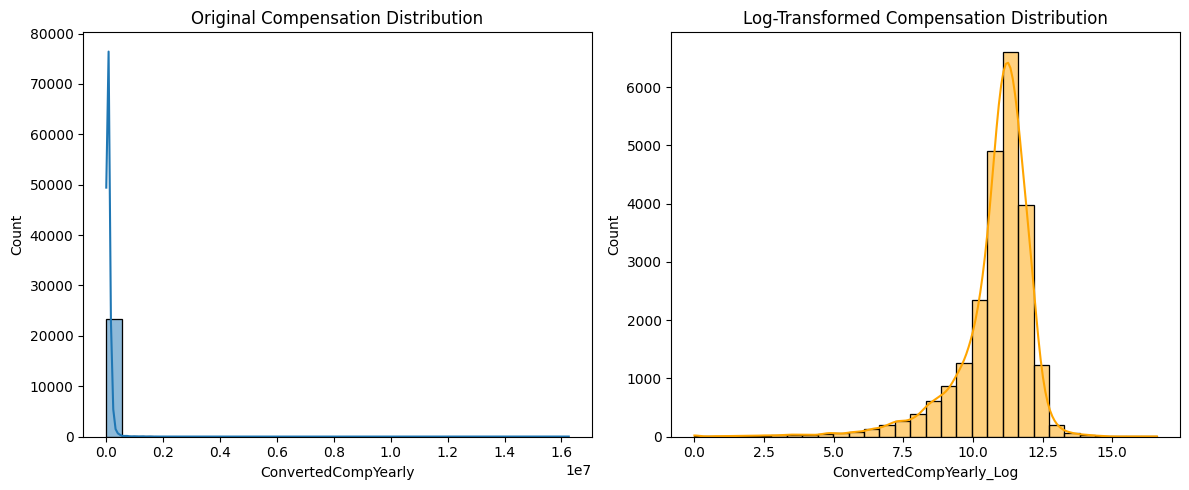

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Original distribution
plt.subplot(1,2,1)
sns.histplot(df["ConvertedCompYearly"], bins=30, kde=True)
plt.title("Original Compensation Distribution")
plt.xlabel("ConvertedCompYearly")

# Log-transformed distribution
plt.subplot(1,2,2)
sns.histplot(df["ConvertedCompYearly_Log"], bins=30, kde=True, color="orange")
plt.title("Log-Transformed Compensation Distribution")
plt.xlabel("ConvertedCompYearly_Log")

plt.tight_layout()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [40]:
# Check unique values in YearsCodePro
print(df["YearsCodePro"].unique()[:20])

<StringArray>
[ '1',  '6', '17',  '7', '18', '25', '30', '20', '50', '27', '16',  '4', '15',
 '11', '23', '10',  '9',  '8', '24', '12']
Length: 20, dtype: str


In [41]:
# Replace text values with numeric equivalents
df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 51
})

# Convert to numeric (coerce errors to NaN)
df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

In [44]:
def categorize_experience(years):
    if pd.isnull(years):
        return "Unknown"
    elif years <= 1:
        return "Beginner"
    elif years <= 5:
        return "Junior"
    elif years <= 10:
        return "Mid-level"
    elif years <= 20:
        return "Senior"
    else:
        return "Expert"

# Apply function to create new column
df["Experience Level"] = df["YearsCodePro"].apply(categorize_experience)

In [45]:
print(df[["YearsCodePro", "Experience Level"]].head(10))
print(df["Experience Level"].value_counts())

     YearsCodePro Experience Level
72            1.0         Beginner
374           6.0        Mid-level
379           6.0        Mid-level
385          17.0           Senior
389           7.0        Mid-level
392          18.0           Senior
395          25.0           Expert
398          30.0           Expert
403          20.0           Senior
409          50.0           Expert
Experience Level
Junior       7053
Mid-level    6305
Senior       5482
Expert       2875
Beginner     1630
Unknown        90
Name: count, dtype: int64


### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.
